# seq2seq grounded dialog generator

- Sequence is a series of things
- We give a sequence of words(How are you?) to machine and the machine replies with an sequence (I am doing good)
- Hence this is known as sequence to sequence (seq2seq)

- seq2seq can be used for translation, Dialog generation etc
- **Basic Architecture:-**

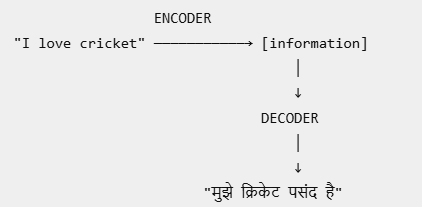

- Encoder = Reads
- Decoder = Generates

- One problem:- When the input is long, and Encoders try to fit all that into an fixed-size vector, The model can forget useful information, Hence We introduce **ATTENTION**

## Attention

- At each step of generating the output, the decoder decides which parts of the input are most relevant right now.

- EX:- You are translating **"The dog that chased the cat was hungry"** into french.
    - You are about to translate the word **"dog"** into **"chien"** hence we will treat the **"dog"** from input with most relevance

- "What part of the input should I look at right now?"

- The decoder gets to look back at the input representations at every generation step.

- 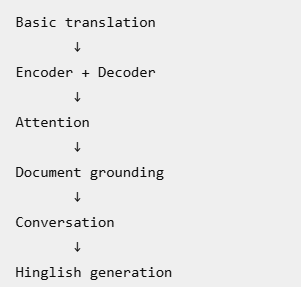

# RNN:-

If we want to process "I love Cricket" in Neural Network, then we will have to normally feed the words I-->Love-->Cricket to the neural network, In any intermediate step it doesnt remember/understand what was the previous information

RNN's can process one element at a time while carrying information from previous elements.

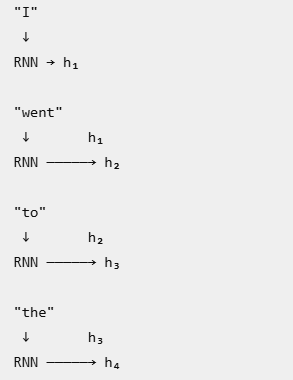

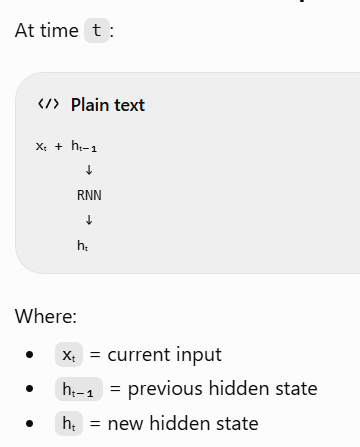

EX:-   "I grew up in india, so i speak _____"

- When the model reaches the blank space, the information from earlier words can influence its prediction

- But Basic **RNNs struggle to remember useful information over long sequences.**

- Hence thats why we got **LSTM(Long short Term Memory)**

### RNN:- An RNN processes a sequence step by step, and its output at each step is influenced by the current input and the hidden information (hidden state) carried from previous steps.

# LSTM:-

- LSTM has a dedicated cell state that can carry information through the sequence, plus gates that control what information to keep, add, and output.

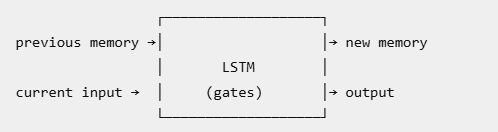

1) Forget Gate:- What old information should I throw away
2) Input Gate:- What new information should I add to my memory?
3) Output Gate:- What part of my memory should I expose as the output right now?

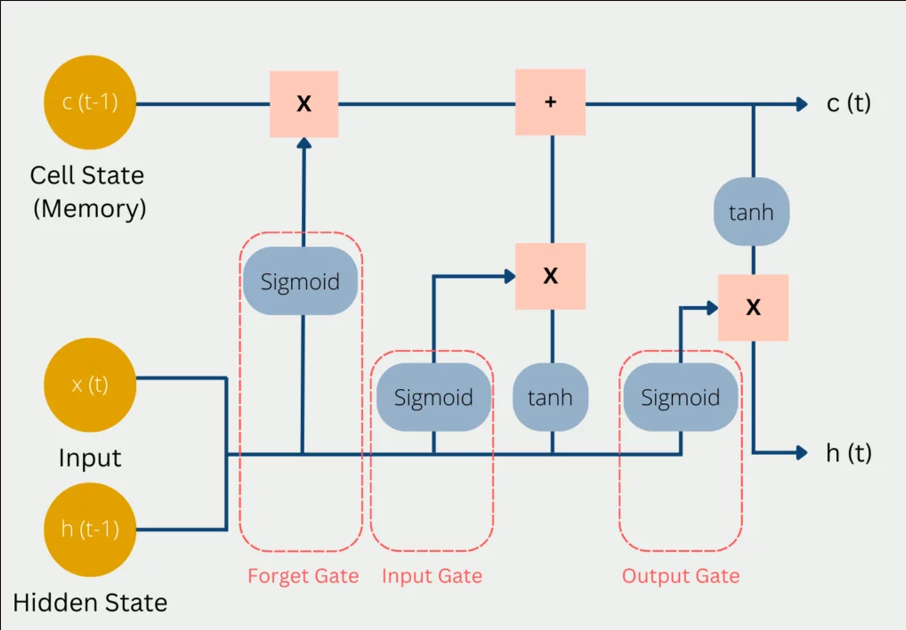

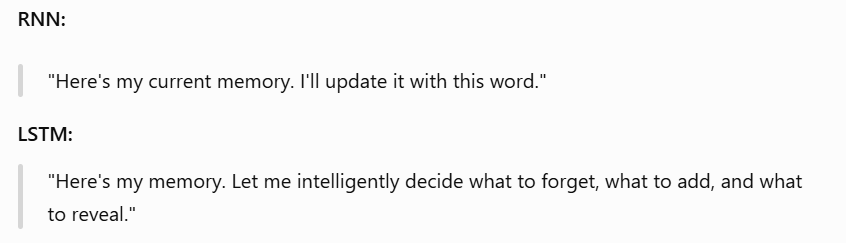

## Cell State vs Hidden State

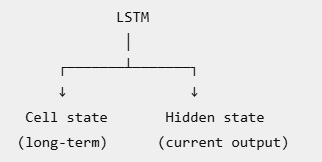

1) Cell state:- 
    - LSTM's long-term memory highway.
    - The LSTM's gates decide what information gets removed from or added to this memory.

2) Hidden state:-
    - This is the information the LSTM is currently exposing
    - It's used as the output of the LSTM at that time step and is also passed to the next step.





1)**Tokenization**:-

- LSTM can't read **"I LOVE CRICKET"**
- Hence we split the sentence into tokens "I LOVE TOKENS"-> ["I","LOVE","CRICKET"]

2)**Vocabulary**:-

- We give each token a unique representation
- We need a representation where similar words can have similar representations.
- I -> 3 , LOVE -> 4 , CRICKET -> 5
- These are just labels, These ID's will be used to Uplook Embeddings

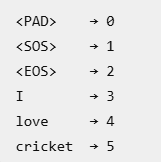

3)**Embedding**:-

- An embedding converts a token ID into a vector.
- "I"       → [0.21, -0.73, 0.15, ...]
- "love"    → [0.82,  0.11, -0.42, ...]
- "cricket" → [-0.31, 0.67, 0.91, ...]


## ENTIRE PIPELINE:-

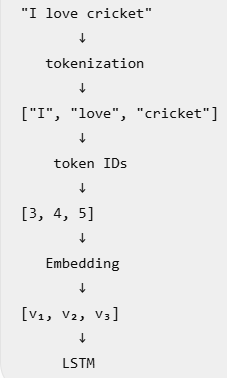

## SPECIAL TOKENS
----------------------------------------------------------------------
1) 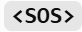
- Start of sequence
- Tells the decoder "Start generating now"
------------------------------------------------------------------------
2) 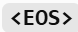
- End of sequence
- Tells the decoder We are finished
- Hence target sentence might look like:- 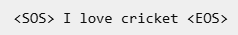

---------------------------------------------------------------------------
3) 
- Suppose we have sentences of different length, we use padding in smaller sentence to match its size to larger sentence
- 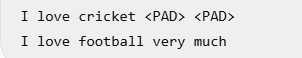


-----------------------------------------------------------------
## Encoder:-
- Read the entire input sequence and turn it into useful representations that the decoder can use.
- Encoder = component/role
- LSTM = architecture used inside that component
- 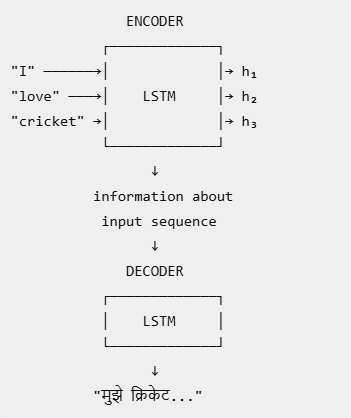
- The encoder is the part of Seq2Seq that reads the input; an LSTM is the neural architecture we can use to implement that encoder.

- Hence basically and Encoder(LSTM) reads the embeddings of each word of an input, and produces hidden state for every input word, and generates final hidden state and final cell state

## Why do we need all the hidden states??

Ex:- 

- h₁ = information about "I"
- h₂ = information about "went"
- h₃ = information about "to"
- h₄ = information about "Bangalore"
- h₅ = information about "yesterday"

Suppose the decoder is generating something about **Banglore**, it will use **attention** to highlight h4 more rather than treating every word equally

- Without Attention, we will be needing only one final Hidden state
but it will be **Compressed representation of the input**
- But compressing long sequence into final state is hard


### Our Architecture So far:- 

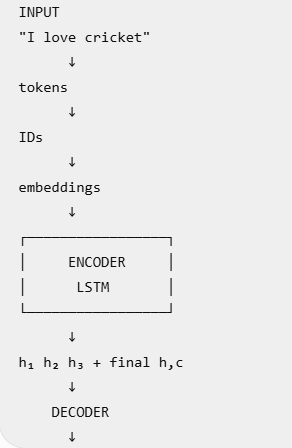



# Decoder:-

- Generates Output
- The decoder doesn't generate the entire sentence at once. 
- It generates **one token at a time**
- Shows **Autoregressive Generation**
- Can be an LSTM
- EX:- Suppose Decoder is Generating मुझे क्रिकेट पसंद है

1) SOS :- "START GENERATING"
2) 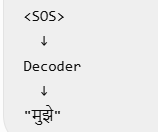  
3) 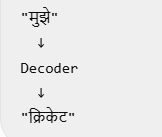  It gets its own previous output 
4) 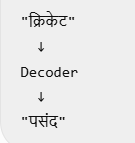
5) 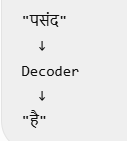
6) 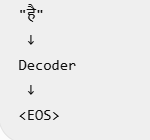
7) EOS :- "STOP GENERATING"

- AS u saw that **The decoder's current prediction depends on what it generated previously.** hence decoders are knows as ***AUTOREGRESSIVE***

- 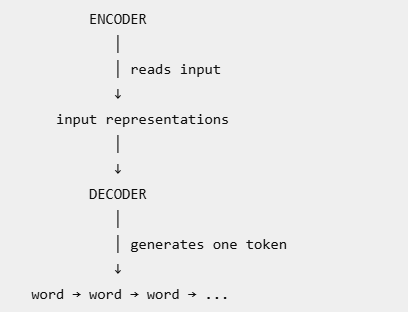

# ATTENTION:- 

- Instead of forcing the decoder to rely on one compressed representation, **it can look back at the encoder's outputs and decide what part of the input matters at each generation step.**
- Attention allows the decoder to dynamically decide which encoder outputs are most relevant when generating each output token.

- EX:- 

If Encoder has generated output as
- I       → h₁
- love    → h₂
- playing → h₃
- cricket → h₄
- with    → h₅
- my      → h₆
- friends → h₇

Now decoder starts translating , suppose it's currently trying to generate the word corresponding to "Cricket", it should pay a lot more attention to h₄
compared to other outputs,

Hence **Attenton creates Weights**

- h₁  → 0.05
- h₂  → 0.10
- h₃  → 0.15
- h₄  → 0.55   ← most important
- h₅  → 0.05
- h₆  → 0.04
- h₇  → 0.06

These weights tells us how much attention to give each encoder state, usually they add up to 1 as we use softmax

Hence we generate something known as **Context Vector** ie

--------------------------------------------------------------------
### CONTEXT VECTOR:- 
- **context = 0.05 h₁ + 0.10 h₂ + 0.15 h₃ + 0.55 h₄ + 0.05 h₅ + 0.04 h₆ + 0.06 h₇**
- Context:- **"Here's the information from the input that is most relevant to what you're generating right now."**
--------------------------------------------------------------------

Attention Weights change at every decoder step, so will the context

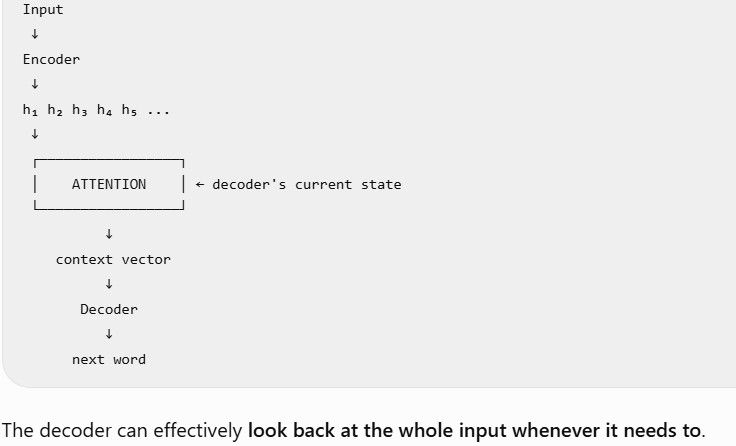



### LETS NOW DISCUSS HOW ATTENTION WEIGHTS ARE OBTAINED

A) At any given decoder step, decoder has two items:-

1) Decoder hidden state = h_decoder
2) All Encoder hidden states = h₁, h₂, h₃, ..., hₙ

B) So we find score of h_decoder with each of the encoder hidden state:
- h_decoder ↔ h₁ → score₁
- h_decoder ↔ h₂ → score₂
- h_decoder ↔ h₃ → score₃
- ...
- h_decoder ↔ hₙ → scoreₙ

C) So higher score = More relevant

D) We apply Softmax to these scores to get Attention Weights
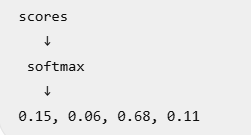

E) Context= weights*Encoder_hidden_states =(0.15h₁ + 0.06h₂ + 0.68h₃ + 0.11h₄)

F) After the attention step, Decoder has two items:-
1) decoder hidden state = h_decoder
2) Context Vector

G) Hence decoder uses these both to predict next word

h) Then decoder moves to next timestep and repeats this loop again


## Bahdanau and Luong

- Bahdanau and Luong are different scoring mechanisms for deciding how much attention to give each encoder output.

1) Bahdanau:- Uses a small neural network to learn the relevance score.
          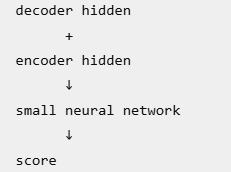

2) Luong :- dot product between decoder_hidden and encoder_hiddens          



# Teacher Forcing:-

- Teacher forcing = during training, give the decoder the correct previous word instead of its own previous prediction.

- Instead of providing models prediction as hidden_decoder for next step, we give it the correct answer

- But sometimes when we dont know the correct answer we will have to use the models predictions like:- 

- 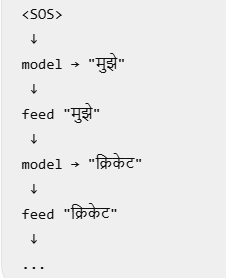

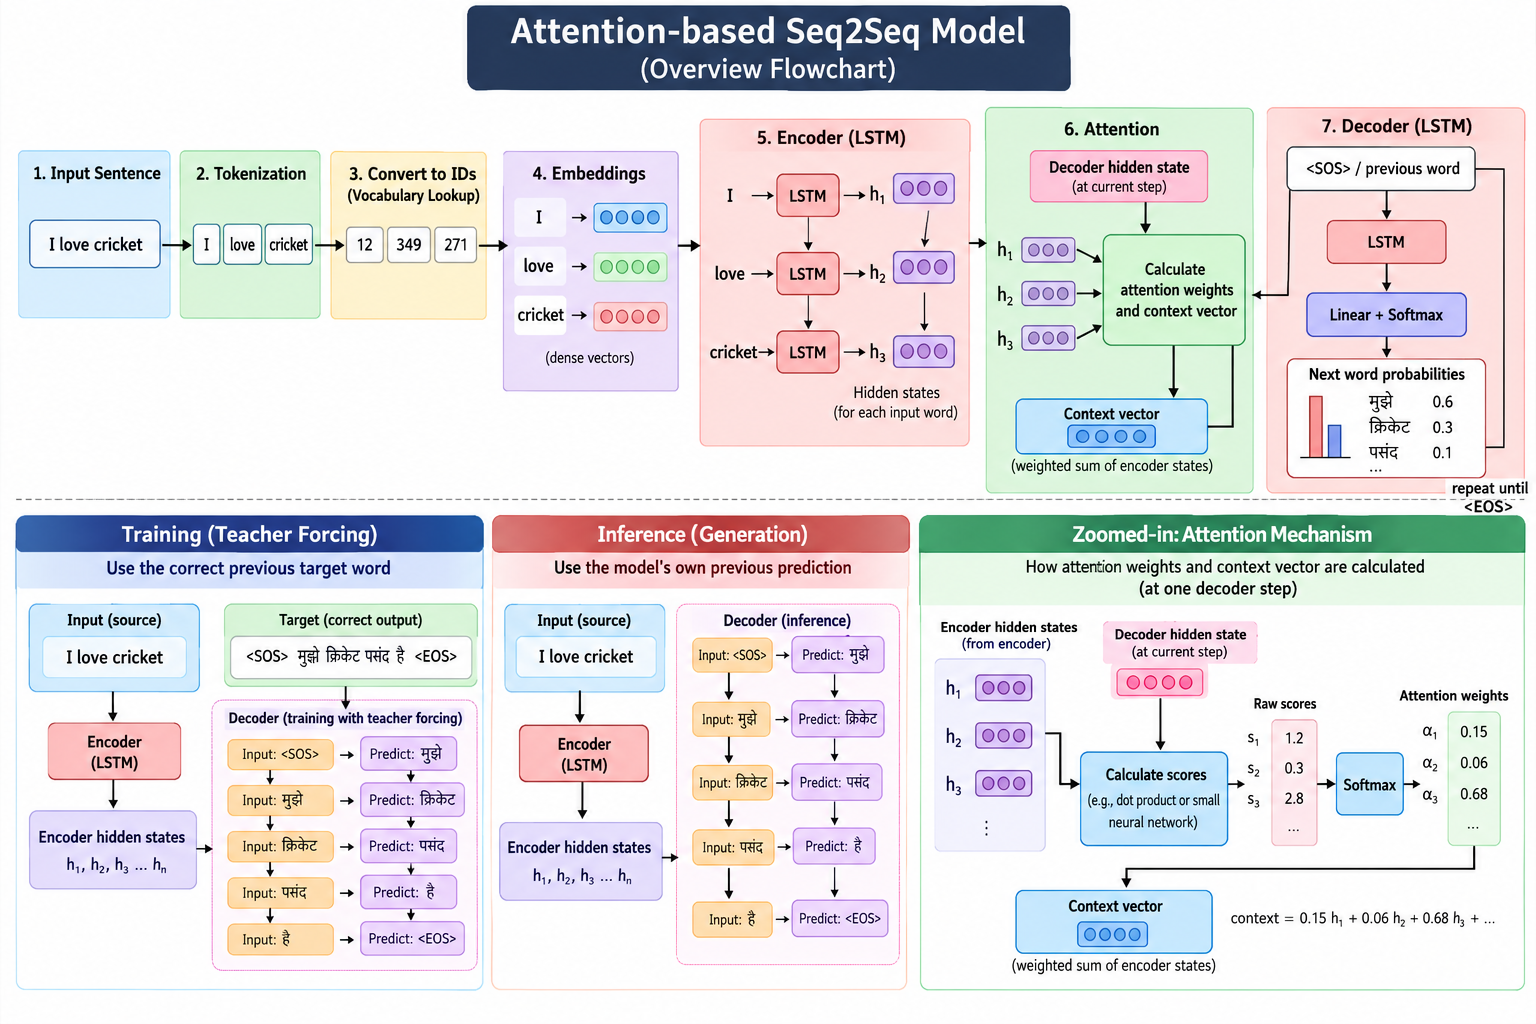

# Understanding SUBTASK1

### 1) CONTEXT
As there is no Attention block needed in SUBTASK1 we can do:- 

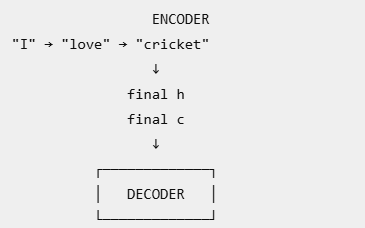

Here the final states h₃ and c₃ carry the encoder's information about the whole input, we commonly call this the **context** or **context representation**

### 2) How does the decoder actually learn?

Ex:- Suppose our target French sentence is:- 'SOS' je aime le cricket 'EOS'

- At every timestep the decoder produces a probability distribution over the entire French vocabulary

- 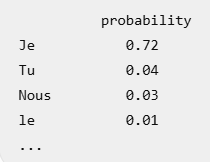
- The model chosses/learns to assign high probability to the correct next token

- This is where **Cross Entropy Loss** comes in

### 3) Loss Function
- Suppose next word is "je" and model predicts:-

1)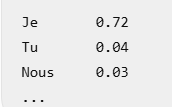 :- Then good (LESS LOSS)

2)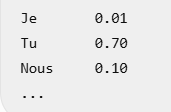 :- Not good (More Loss)

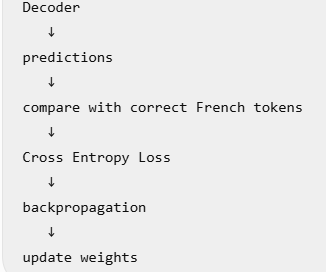  This happens for every output token

### 4) What does the training loop actually look like?

Ex:- 1 training example

- English:- I love Cricket , French:- J'aime le cricket
- The model produces four predictions, and we calculate loss over those predictions
- 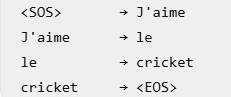
- 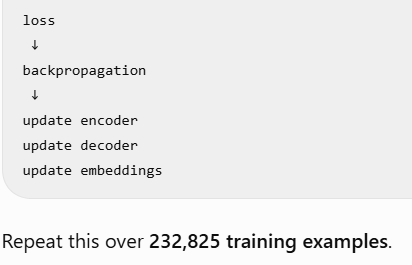

- FINAL TRAINING FLOWCHART

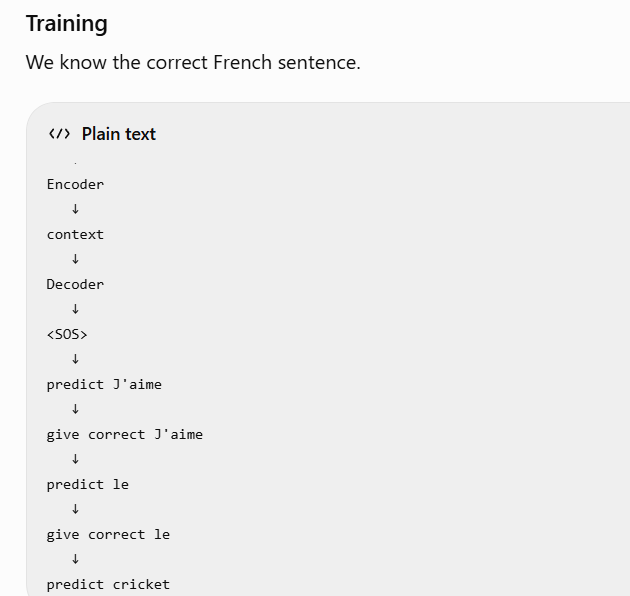

### 5) Prediction/Inference of test sentence

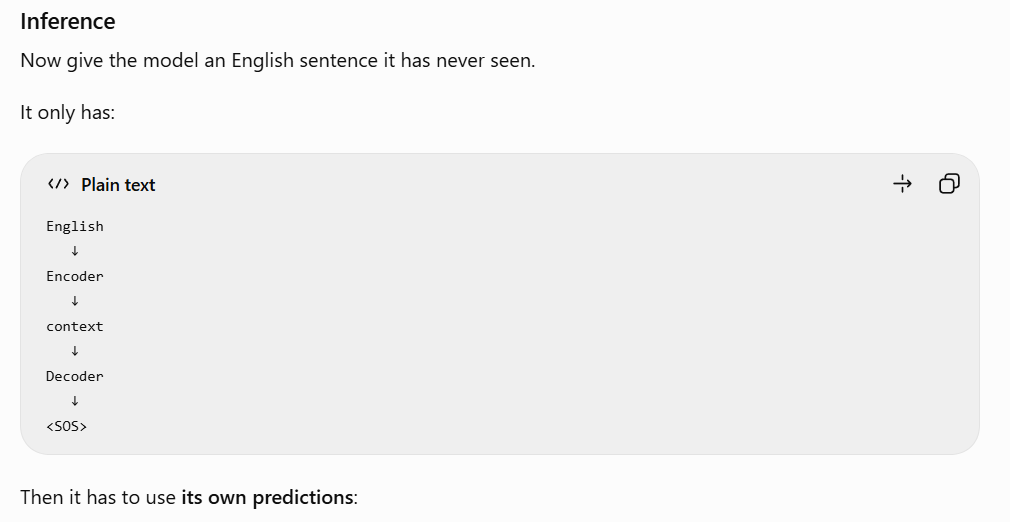
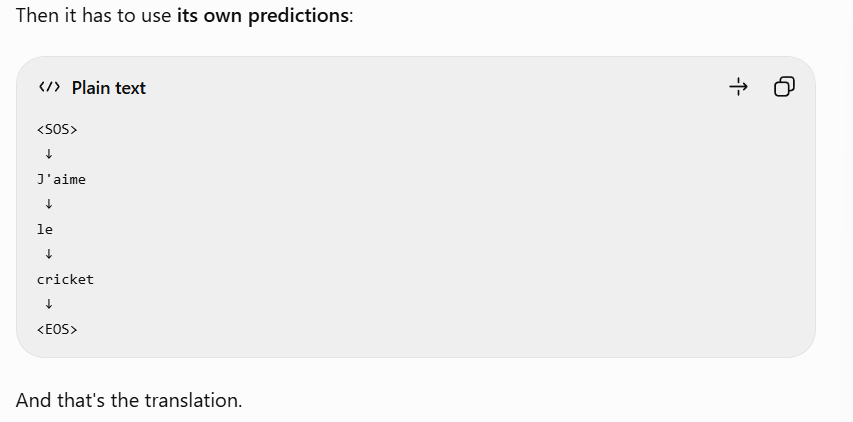

- Simplest stratergy is **Greedy decoding**
- Greedy Decoding:- At every step pick the word with highest probability

### 6) Evaluate using BLEU score

- Belu :- "How much does my generated translation overlap with the reference translation in terms of word sequences?"
- Belu looks at n-gram
- BLEU rewards translations that share meaningful word sequences with the reference.
- Bleu isnt perfect at handeling examples like this:-
    - Reference:- I love this movie
    - Model:- I really like this film